In [1]:
from pathlib import Path
from typing import Any
import numpy as np
from dataclasses import dataclass

from my_types import Quat, ScalarBatch, Vec3Batch, QuatBatch
from io_csv import load_gyro_base, load_ref, load_acc, load_mag, load_grav_ref, load_acc_lin_ref, read_best_from_log
from pipelines import generate_m_ref_world_h_unit, integrate_gyro_acc_mag
from evaluation import calc_angle_err, print_err_status, score_angle_err
from evaluation import save_err_csv, plot_err_from_csv, plot_err_colored_by_weight
from evaluation import save_estimated_vec3_csv, evaluate_estimated_vec3_autosign, calc_vec3_direction_angle_err
from resample import find_stable_start_idx, cut_sample
from autotune import auto_setup_imu_frame, quasi_static_detector, suggest_fixed_gate_sigma
from optuna_exp_3 import exp_3_1, exp_3_2, exp_3_3, exp_3_4, exp_3_5, exp_3_6
from Tee import Tee

SIGMA_FLOOR: float = 1e-3
EPS: float = 1e-9

In [2]:
sample_1: str = "data01_21:08_oct_07_2025_5min"
sample_2: str = "data02_21:23_oct_07_2025_9min"
sample_3: str = "data03_21:41_oct_07_2025_13min"
sample_4: str = "data04_18:52_oct_08_2025_96min"

sample: str = sample_1

root: Path = Path.cwd().parent
run_dir: Path = root / "data" / sample

ori_path: Path = run_dir / "Orientation.csv"
gyro_path: Path = run_dir / "Gyroscope.csv"
acc_path: Path = run_dir / "AccelerometerUncalibrated.csv"
mag_path: Path = run_dir / "Magnetometer.csv"
grav_path: Path = run_dir / "Gravity.csv"
acc_lin_path: Path = run_dir / "Accelerometer.csv"

for p in [ori_path, gyro_path, acc_path, mag_path, grav_path, acc_lin_path]:
        if not p.exists():
                raise FileNotFoundError(f"File not found: {p}")

out_dir: Path = root / "output" / sample / "exp_3"
out_dir.mkdir(parents=True, exist_ok=True)

path_log: Path = out_dir / "03_exp3_log.txt"
path_err_1: Path = out_dir / "03_exp3-1_angle_err.csv"
path_err_2: Path = out_dir / "03_exp3-2_angle_err.csv"
path_err_3: Path = out_dir / "03_exp3-3_angle_err.csv"
path_err_4: Path = out_dir / "03_exp3-4_angle_err.csv"
path_err_5: Path = out_dir / "03_exp3-5_angle_err.csv"
path_err_6: Path = out_dir / "03_exp3-6_angle_err.csv"

path_plot: Path = out_dir / "03_exp3_plot.png"
path_plot_weight: Path = out_dir / "03_exp3_plot_weight.png"

path_est_grav: Path = out_dir / "03_exp3_grav_est.csv"
path_est_acc: Path = out_dir / "03_exp3_acc_lin_est.csv"


for p in [path_log, path_err_1, path_err_2, path_err_3, path_err_4, path_err_5, path_err_6,
          path_plot, path_plot_weight, path_est_grav, path_est_acc]:
        if p.is_file():
                p.unlink()

In [3]:
with Tee(path_log):
        t_src_gyro, w_src_gyro, dt, t_new, w_avg_gyro = load_gyro_base(gyro_path)

        q_ref_interp = load_ref(ori_path, t_new)
        q_ref_interp /= np.linalg.norm(q_ref_interp, axis=1, keepdims=True)

        g_ref_interp = load_grav_ref(grav_path, t_new)
        a_lin_ref_interp = load_acc_lin_ref(acc_lin_path, t_new)

        idx_cut: int = find_stable_start_idx(dt, w_avg_gyro, q_ref_interp,
                                             sample_window=1000, threshold=0.5, sample_hz=100,
                                             consecutive=3, min_cut_second=10, max_cut_second=30)
        t_cut: int = idx_cut / 100
        a_src_interp = load_acc(acc_path, t_new)
        m_src_interp = load_mag(mag_path, t_new)
        [dt, t_new, w_avg_gyro, q_ref_interp,
         a_src_interp, m_src_interp,
         g_ref_interp, a_lin_ref_interp] = cut_sample(idx_cut,
                                                      [dt, t_new, w_avg_gyro, q_ref_interp,
                                                       a_src_interp, m_src_interp,
                                                       g_ref_interp, a_lin_ref_interp])



[START] 2026-03-26 16:47:09.406

[INFO] Stabilization detected too early (< min_cut), applying min_cut=10s policy

[END] 2026-03-26 16:47:10.111




In [4]:
with Tee(path_log):
        q0: Quat = q_ref_interp[0].copy()
        g0: float = 9.80665
        a_src_interp, g_world_unit = auto_setup_imu_frame(q_ref_interp, w_avg_gyro, dt,
                                                          g0, a_src_interp)
        print("")

        m0: float = np.median(np.linalg.norm(m_src_interp, axis=1))
        m_ref_world_h_unit = generate_m_ref_world_h_unit(g0, g_world_unit, 5000,
                                                         q_ref_interp, a_src_interp, m_src_interp)
        
        best_quasi_static = quasi_static_detector(w_avg_gyro, a_src_interp, dt, g0,
                                                  w_thr=4, a_thr=4,
                                                  min_duration_s=0.5, smooth_win=5)
        print("")

        gyro_gate_sigma, acc_gate_sigma, mag_gate_sigma = suggest_fixed_gate_sigma(
                                                                w_avg_gyro, a_src_interp, m_src_interp,
                                                                g0, m0,
                                                                p_gyro=90, p_acc=90, p_mag=90, sigma_floor=SIGMA_FLOOR,
                                                                best_quasi_static=best_quasi_static)



[START] 2026-03-26 16:47:10.126

Detected accel unit in [m/s²]
Selected g_world_unit: [ 0  0 -1]

Best quasi static(start, end, length):  (2523, 3540, 1017)

Suggested gyro_sigma:  0.44791971689543864
Suggested acc_sigma:  2.908568806018301
Suggested mag_sigma:  6.850455808768257

[END] 2026-03-26 16:47:11.086




In [5]:
def runner_exp3(*,
               K: float,
               mag_gain: float,
               acc_gate_sigma: float = np.inf,
               gyro_gate_sigma: float = np.inf,
               mag_gate_sigma: float = np.inf,
               mag_err_sigma: float = np.inf,
               **kwargs: Any):
        q_est, g_body_est, a_lin_est, weight_acc, weight_gyro, weight_mag  = integrate_gyro_acc_mag(
                                                                q0, w_avg_gyro, dt,
                                                                K, g0, g_world_unit,
                                                                m0, m_ref_world_h_unit, mag_gain,
                                                                acc_gate_sigma, gyro_gate_sigma,
                                                                mag_gate_sigma, mag_err_sigma,
                                                                a_src_interp, m_src_interp)
        return q_est, (g_body_est, a_lin_est, weight_acc, weight_gyro, weight_mag)

In [6]:
@dataclass
class Data:
        exp: str
        q_est: QuatBatch
        g_body_est: Vec3Batch
        a_lin_est: Vec3Batch
        mag_gain: float
        weight_acc: ScalarBatch
        weight_gyro: ScalarBatch
        weight_mag: ScalarBatch
        angle_err: ScalarBatch

In [7]:
# exp 3-1: Gyro+Acc+Mag without any gating

with Tee(path_log):
        best_tau_1, best_K_1, best_mag_gain_1 = exp_3_1(dt=dt, q_ref=q_ref_interp,
                                                        best_quasi_static=best_quasi_static,
                                                        tau_candidate=(0.1, 4),
                                                        mag_gain_candidate=(0.01, 10),
                                                        runner_func=runner_exp3,
                                                        n_trials=20)

        print("\n[chosen value]")
        print("tau=", best_tau_1, ", K=", best_K_1)
        print("mag_gain=", best_mag_gain_1)
        print("acc_gate_sigma=inf")
        print("gyro_gate_sigma=inf")
        print("mag_gate_sigma=inf")
        print("mag_err_sigma=inf\n")

        [q_est_1, g_body_est_1, a_lin_est_1,
         weight_acc_1, weight_gyro_1, weight_mag_1] = integrate_gyro_acc_mag(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_1, g0, g_world_unit,
                                                        m0, m_ref_world_h_unit, best_mag_gain_1,
                                                        np.inf, np.inf,
                                                        np.inf, np.inf,
                                                        a_src_interp, m_src_interp)

        angle_err_1: ScalarBatch = calc_angle_err(q_est_1, q_ref_interp)
        print_err_status("[exp 3-1] Gyro+Acc+Mag", angle_err_1)

        data_exp1: Data = Data("[exp3-1] ", q_est_1, g_body_est_1, a_lin_est_1, best_mag_gain_1,
                               weight_acc_1, weight_gyro_1, weight_mag_1, angle_err_1)

[I 2026-03-26 16:47:11,141] A new study created in memory with name: no-name-4576207c-afea-415e-a5e8-0083bf7fd15b




[START] 2026-03-26 16:47:11.139



[I 2026-03-26 16:47:20,885] Trial 0 finished with value: 0.3942906564425004 and parameters: {'tau': 1.5607064635047139, 'mag_gain': 9.507635921035062}. Best is trial 0 with value: 0.3942906564425004.
[I 2026-03-26 16:47:30,108] Trial 1 finished with value: 0.2594931446575077 and parameters: {'tau': 2.95477637306448, 'mag_gain': 5.990598257128395}. Best is trial 1 with value: 0.2594931446575077.
[I 2026-03-26 16:47:39,674] Trial 2 finished with value: 0.29467737409673717 and parameters: {'tau': 0.7084726977255024, 'mag_gain': 1.5683852581586646}. Best is trial 1 with value: 0.2594931446575077.
[I 2026-03-26 16:47:49,318] Trial 3 finished with value: 0.46664812383829607 and parameters: {'tau': 0.3265260874559779, 'mag_gain': 8.663099696291603}. Best is trial 1 with value: 0.2594931446575077.
[I 2026-03-26 16:47:58,805] Trial 4 finished with value: 0.4308162249032396 and parameters: {'tau': 2.4443485457985146, 'mag_gain': 7.0836450521824945}. Best is trial 1 with value: 0.2594931446575077


[chosen value]
tau= 3.932469060126895 , K= 0.0025426212244773093
mag_gain= 3.5771776662400905
acc_gate_sigma=inf
gyro_gate_sigma=inf
mag_gate_sigma=inf
mag_err_sigma=inf

[exp 3-1] Gyro+Acc+Mag angle error in rad — min/max/mean/p90
0.002818835027033219 0.7172417482362367 0.042172969711376365 0.08175313998327868

[exp 3-1] Gyro+Acc+Mag angle error in deg — min/max/mean/p90
0.16150735019264875 41.09492506452112 2.416333173994919 4.68410988298409

[END] 2026-03-26 16:50:30.032




In [8]:
# exp 3-2: Gyro+Acc+Mag+Gating(Mag innov)

with Tee(path_log):
        [best_tau_2, best_K_2, best_mag_gain_2,
         best_mag_err_sigma_2] = exp_3_2(dt=dt, q_ref=q_ref_interp,
                                         best_quasi_static=best_quasi_static,
                                         tau_candidate=(best_tau_1 * 0.9, best_tau_1 * 1.1),
                                         mag_gain_candidate=(best_mag_gain_1 * 0.7, best_mag_gain_1 * 1.3),
                                         mag_err_sigma_candidate=(0.01, 2),
                                         runner_func=runner_exp3,
                                         n_trials=20)

        print("\n[chosen value]")
        print("tau=", best_tau_2, ", K=", best_K_2)
        print("mag_gain=", best_mag_gain_2)
        print("acc_gate_sigma=inf")
        print("gyro_gate_sigma=inf")
        print("mag_gate_sigma=inf")
        print(f"mag_err_sigma={best_mag_err_sigma_2:.7f}\n")

        [q_est_2, g_body_est_2, a_lin_est_2,
        weight_acc_2, weight_gyro_2, weight_mag_2] = integrate_gyro_acc_mag(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_2, g0, g_world_unit,
                                                        m0, m_ref_world_h_unit, best_mag_gain_2,
                                                        np.inf, np.inf,
                                                        np.inf, best_mag_err_sigma_2,
                                                        a_src_interp, m_src_interp)        
        angle_err_2: ScalarBatch = calc_angle_err(q_est_2, q_ref_interp)
        print_err_status("[exp 3-2] Gyro+Acc+Mag+Gating(Mag_innov)", angle_err_2)

        data_exp2: Data = Data("[exp3-2] ", q_est_2, g_body_est_2, a_lin_est_2, best_mag_gain_2,
                               weight_acc_2, weight_gyro_2, weight_mag_2, angle_err_2)

[I 2026-03-26 16:50:30,048] A new study created in memory with name: no-name-1cd54594-cff5-460c-ab1f-0db957498b19




[START] 2026-03-26 16:50:30.047



[I 2026-03-26 16:50:39,645] Trial 0 finished with value: 0.18727222121005818 and parameters: {'tau': 3.833795639942906, 'mag_gain': 4.5445487566867575, 'mag_err_sigma': 1.4666679442046962}. Best is trial 0 with value: 0.18727222121005818.
[I 2026-03-26 16:50:49,188] Trial 1 finished with value: 0.18831885549175909 and parameters: {'tau': 4.010063347451668, 'mag_gain': 2.8388882040327594, 'mag_err_sigma': 0.3204290954690433}. Best is trial 0 with value: 0.18727222121005818.
[I 2026-03-26 16:50:58,765] Trial 2 finished with value: 0.1916671382041584 and parameters: {'tau': 3.5849045556645764, 'mag_gain': 4.363103944585674, 'mag_err_sigma': 1.2062188733689856}. Best is trial 0 with value: 0.18727222121005818.
[I 2026-03-26 16:51:08,483] Trial 3 finished with value: 0.17161411818817096 and parameters: {'tau': 4.096116855015654, 'mag_gain': 2.548205002327538, 'mag_err_sigma': 1.9401206058023688}. Best is trial 3 with value: 0.17161411818817096.
[I 2026-03-26 16:51:18,192] Trial 4 finished w


[chosen value]
tau= 4.282566197670456 , K= 0.002334763512194607
mag_gain= 3.519929920245394
acc_gate_sigma=inf
gyro_gate_sigma=inf
mag_gate_sigma=inf
mag_err_sigma=1.6224342

[exp 3-2] Gyro+Acc+Mag+Gating(Mag_innov) angle error in rad — min/max/mean/p90
0.00280806873989446 0.6962182150580377 0.04136929699102485 0.07967920247718345

[exp 3-2] Gyro+Acc+Mag+Gating(Mag_innov) angle error in deg — min/max/mean/p90
0.1608904873785719 39.89036534295706 2.37028611900898 4.565282016910945

[END] 2026-03-26 16:53:51.713




In [9]:
# exp 3-3: Gyro+Acc+Mag+Gating(Gyro/Acc/Mag norm) — fixed sigma

with Tee(path_log):
        [best_tau_3, best_K_3, best_mag_gain_3,
         best_acc_sigma_3, best_gyro_sigma_3, best_mag_sigma_3] = exp_3_3(
                                                                dt=dt, q_ref=q_ref_interp,
                                                                best_quasi_static=best_quasi_static,
                                                                tau_candidate=(best_tau_2 * 0.9, best_tau_2 * 1.1),
                                                                mag_gain_candidate=(best_mag_gain_2 * 0.7, best_mag_gain_2 * 1.3),
                                                                acc_gate_sigma_candidate=(0.01*acc_gate_sigma, 10*acc_gate_sigma),
                                                                gyro_gate_sigma_candidate=(0.1*gyro_gate_sigma, 10*gyro_gate_sigma),
                                                                mag_gate_sigma_candidate=(0.01*mag_gate_sigma, 10*mag_gate_sigma),
                                                                runner_func=runner_exp3,
                                                                n_trials=30)

        print("\n[chosen value]")
        print("tau=", best_tau_3, ", K=", best_K_3)
        print("mag_gain=", best_mag_gain_3)
        print(f"acc_gate_sigma={best_acc_sigma_3:.7f}")
        print(f"gyro_gate_sigma={best_gyro_sigma_3:.7f}")
        print(f"mag_gate_sigma={best_mag_sigma_3:.7f}")
        print("mag_err_sigma=inf\n")

        [q_est_3, g_body_est_3, a_lin_est_3,
        weight_acc_3, weight_gyro_3, weight_mag_3] = integrate_gyro_acc_mag(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_3, g0, g_world_unit,
                                                        m0, m_ref_world_h_unit, best_mag_gain_3,
                                                        best_acc_sigma_3, best_gyro_sigma_3,
                                                        best_mag_sigma_3, np.inf,
                                                        a_src_interp, m_src_interp)        
        angle_err_3: ScalarBatch = calc_angle_err(q_est_3, q_ref_interp)
        print_err_status("[exp 3-3] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm)", angle_err_3)

        data_exp3: Data = Data("[exp3-3] ", q_est_3, g_body_est_3, a_lin_est_3, best_mag_gain_3,
                               weight_acc_3, weight_gyro_3, weight_mag_3, angle_err_3)

[I 2026-03-26 16:53:51,729] A new study created in memory with name: no-name-03127434-2f9a-4ecc-92fa-80c8ff6f8deb




[START] 2026-03-26 16:53:51.728



[I 2026-03-26 16:54:03,049] Trial 0 finished with value: 0.18034901676883347 and parameters: {'tau': 4.175108148432849, 'mag_gain': 4.471819583814343, 'acc_gate_sigma': 21.298342594076995, 'gyro_gate_sigma': 2.699486265399576, 'mag_gate_sigma': 10.745804587020885}. Best is trial 0 with value: 0.18034901676883347.
[I 2026-03-26 16:54:14,352] Trial 1 finished with value: 0.16815603868581064 and parameters: {'tau': 3.987920949866138, 'mag_gain': 2.58662109077984, 'acc_gate_sigma': 25.197221540060372, 'gyro_gate_sigma': 2.710379503917546, 'mag_gate_sigma': 48.52619739497609}. Best is trial 1 with value: 0.16815603868581064.
[I 2026-03-26 16:54:25,941] Trial 2 finished with value: 0.1633360998093542 and parameters: {'tau': 3.8719404697968796, 'mag_gain': 4.512359769311249, 'acc_gate_sigma': 24.217040499397907, 'gyro_gate_sigma': 0.9863896276638863, 'mag_gate_sigma': 12.511887746889654}. Best is trial 2 with value: 0.1633360998093542.
[I 2026-03-26 16:54:37,211] Trial 3 finished with value: 


[chosen value]
tau= 4.572570503039086 , K= 0.0021866867422237557
mag_gain= 4.397713410255224
acc_gate_sigma=20.4765482
gyro_gate_sigma=1.1233809
mag_gate_sigma=25.3407412
mag_err_sigma=inf

[exp 3-3] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm) angle error in rad — min/max/mean/p90
0.0022300678365621764 0.5431561440288503 0.038150425089703295 0.07351459839444256

[exp 3-3] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm) angle error in deg — min/max/mean/p90
0.12777347506288297 31.12055466945299 2.1858583442700037 4.2120762206007765

[END] 2026-03-26 16:59:42.931




In [10]:
# exp 3-4: Gyro+Acc+Mag+Gating(Gyro/Acc/Mag norm + Mag innov) — fixed sigma

with Tee(path_log):
        [best_tau_4, best_K_4, best_mag_gain_4,
         best_acc_sigma_4, best_gyro_sigma_4, best_mag_sigma_4,
         best_mag_err_sigma_4] = exp_3_4(dt=dt, q_ref=q_ref_interp,
                                         best_quasi_static=best_quasi_static,
                                         tau_candidate=(best_tau_3 * 0.9, best_tau_3 * 1.1),
                                         mag_gain_candidate=(best_mag_gain_3 * 0.7, best_mag_gain_3 * 1.3),
                                         acc_gate_sigma_candidate=(best_acc_sigma_3 * 0.7, best_acc_sigma_3 * 1.3),
                                         gyro_gate_sigma_candidate=(best_gyro_sigma_3 * 0.7, best_gyro_sigma_3 * 1.3),
                                         mag_gate_sigma_candidate=(best_mag_sigma_3 * 0.7, best_mag_sigma_3 * 1.3),
                                         mag_err_sigma_candidate=(best_mag_err_sigma_2 * 0.5, best_mag_err_sigma_2 * 1.5),
                                         runner_func=runner_exp3,
                                         n_trials=20)

        print("\n[chosen value]")
        print("tau=", best_tau_4, ", K=", best_K_4)
        print("mag_gain=", best_mag_gain_4)
        print(f"acc_gate_sigma={best_acc_sigma_4:.7f}")
        print(f"gyro_gate_sigma={best_gyro_sigma_4:.7f}")
        print(f"mag_gate_sigma={best_mag_sigma_4:.7f}")
        print(f"mag_err_sigma={best_mag_err_sigma_4:.7f}\n")

        [q_est_4, g_body_est_4, a_lin_est_4,
        weight_acc_4, weight_gyro_4, weight_mag_4] = integrate_gyro_acc_mag(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_4, g0, g_world_unit,
                                                        m0, m_ref_world_h_unit, best_mag_gain_4,
                                                        best_acc_sigma_4, best_gyro_sigma_4,
                                                        best_mag_sigma_4, best_mag_err_sigma_4,
                                                        a_src_interp, m_src_interp)
        angle_err_4: ScalarBatch = calc_angle_err(q_est_4, q_ref_interp)
        print_err_status("[exp 3-4] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm+Mag_innov)", angle_err_4)

        data_exp4: Data = Data("[exp3-4] ", q_est_4, g_body_est_4, a_lin_est_4, best_mag_gain_4,
                               weight_acc_4, weight_gyro_4, weight_mag_4, angle_err_4)

[I 2026-03-26 16:59:42,949] A new study created in memory with name: no-name-c205955e-52bb-49dd-ba88-3419f7f2454f




[START] 2026-03-26 16:59:42.948



[I 2026-03-26 16:59:54,283] Trial 0 finished with value: 0.15515138682292312 and parameters: {'tau': 4.457835672664418, 'mag_gain': 5.586980819950886, 'acc_gate_sigma': 23.32680926618312, 'gyro_gate_sigma': 1.1898795496691803, 'mag_gate_sigma': 20.110695658746007, 'mag_err_sigma': 1.0643079153570838}. Best is trial 0 with value: 0.15515138682292312.
[I 2026-03-26 17:00:05,678] Trial 1 finished with value: 0.15500490162138938 and parameters: {'tau': 4.168431735077231, 'mag_gain': 5.363916058329227, 'acc_gate_sigma': 21.718840035120728, 'gyro_gate_sigma': 1.2636277724004736, 'mag_gate_sigma': 18.051494667914692, 'mag_err_sigma': 2.384831949077234}. Best is trial 1 with value: 0.15500490162138938.
[I 2026-03-26 17:00:17,316] Trial 2 finished with value: 0.15610913419498068 and parameters: {'tau': 4.876593985694371, 'mag_gain': 3.6386833199095707, 'acc_gate_sigma': 16.56747235390927, 'gyro_gate_sigma': 0.9099865159419042, 'mag_gate_sigma': 22.364353232201218, 'mag_err_sigma': 1.66259983534


[chosen value]
tau= 4.7699779116997645 , K= 0.002096189852861593
mag_gain= 5.678210094405326
acc_gate_sigma=15.8903128
gyro_gate_sigma=0.9994370
mag_gate_sigma=18.0364040
mag_err_sigma=1.5374059

[exp 3-4] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm+Mag_innov) angle error in rad — min/max/mean/p90
0.0017333672375821516 0.5303552091541307 0.037937464957498106 0.07606885323359422

[exp 3-4] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm+Mag_innov) angle error in deg — min/max/mean/p90
0.09931462705970755 30.387115127309734 2.1736566274900984 4.358424242685033

[END] 2026-03-26 17:03:45.382




In [11]:
# exp 3-5: Gyro+Acc+Mag+Gating(Gyro/Acc/Mag norm) — time-varying sigma

with Tee(path_log):
        [best_tau_5, best_K_5, best_mag_gain_5,
         best_p_5, best_win_s_5, best_update_ratio_5, best_ema_alpha_5,
         timevarying_acc_sigma_5, timevarying_gyro_sigma_5, timevarying_mag_sigma_5
         ] = exp_3_5(dt=dt, q_ref=q_ref_interp,
                     g0=g0, sigma_floor=SIGMA_FLOOR,
                     w=w_avg_gyro, a=a_src_interp, m=m_src_interp,
                     best_quasi_static=best_quasi_static,
                     tau_candidate=(best_tau_4 * 0.9, best_tau_4 * 1.1),
                     mag_gain_candidate=(best_mag_gain_4 * 0.7, best_mag_gain_4 * 1.3),
                     p_candidate=(50, 80),
                     win_s_candidate=(5, 10),
                     update_ratio_candidate=(0.1, 0.5),
                     ema_candidate=(0.02, 0.2),
                     runner_func=runner_exp3,
                     n_trials=40)

        print("\n[chosen value]")
        print("tau=", best_tau_5, ", K=", best_K_5)
        print("mag_gain=", best_mag_gain_5)
        print("acc/gyro/mag_gate_sigma = time-varying gate sigma")
        print("best_p=", best_p_5, ", best_win_s=", best_win_s_5)
        print("best_update_ratio=", best_update_ratio_5, ", best_ema_alpha=", best_ema_alpha_5)
        print("mag_err_sigma=inf\n")

        [q_est_5, g_body_est_5, a_lin_est_5,
        weight_acc_5, weight_gyro_5, weight_mag_5] = integrate_gyro_acc_mag(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_5, g0, g_world_unit,
                                                        m0, m_ref_world_h_unit, best_mag_gain_5,
                                                        timevarying_acc_sigma_5, timevarying_gyro_sigma_5,
                                                        timevarying_mag_sigma_5, np.inf,
                                                        a_src_interp, m_src_interp)    

        angle_err_5: ScalarBatch = calc_angle_err(q_est_5, q_ref_interp)
        print_err_status("[exp 3-5] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm) ", angle_err_5)

        data_exp5: Data = Data("[exp3-5] ", q_est_5, g_body_est_5, a_lin_est_5, best_mag_gain_5,
                               weight_acc_5, weight_gyro_5, weight_mag_5, angle_err_5)

[I 2026-03-26 17:03:45,401] A new study created in memory with name: no-name-6f57547c-1a6f-4173-bcf4-1c023e919496




[START] 2026-03-26 17:03:45.400



[I 2026-03-26 17:03:56,834] Trial 0 finished with value: 0.2707172497185323 and parameters: {'tau': 4.650289739319253, 'mag_gain': 7.213760409015135, 'p': 72, 'win_s': 7.993292420985183, 'update_ratio': 0.1624074561769746, 'ema_alpha': 0.04807901366051648}. Best is trial 0 with value: 0.2707172497185323.
[I 2026-03-26 17:04:08,458] Trial 1 finished with value: 0.3051076664845823 and parameters: {'tau': 4.348391629944597, 'mag_gain': 6.92574514676713, 'p': 68, 'win_s': 8.540362888980226, 'update_ratio': 0.10823379771832098, 'ema_alpha': 0.194583773389159}. Best is trial 0 with value: 0.2707172497185323.
[I 2026-03-26 17:04:20,212] Trial 2 finished with value: 0.2967884843637642 and parameters: {'tau': 5.087126722404795, 'mag_gain': 4.698170715097991, 'p': 55, 'win_s': 5.917022549267169, 'update_ratio': 0.2216968971838151, 'ema_alpha': 0.11445615769380282}. Best is trial 0 with value: 0.2707172497185323.
[I 2026-03-26 17:04:31,776] Trial 3 finished with value: 0.272678154276156 and param


[chosen value]
tau= 5.173698030271023 , K= 0.0019326174891492838
mag_gain= 4.930731964833801
acc/gyro/mag_gate_sigma = time-varying gate sigma
best_p= 76 , best_win_s= 5.777591402642944
best_update_ratio= 0.39546840952149465 , best_ema_alpha= 0.050896341548929844
mag_err_sigma=inf

[exp 3-5] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm)  angle error in rad — min/max/mean/p90
0.002409636697114314 0.7816545685336467 0.05958371638396706 0.1093147442364582

[exp 3-5] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm)  angle error in deg — min/max/mean/p90
0.13806201290449366 44.785507814097315 3.4138954765058074 6.263273483301096

[END] 2026-03-26 17:11:37.212




In [12]:
# exp 3-6: Gyro+Acc+Mag+Gating(Gyro/Acc/Mag norm + Mag innov) — time-varying sigma

with Tee(path_log):
        [best_tau_6, best_K_6, best_mag_gain_6,
         best_p_6, best_win_s_6, best_update_ratio_6, best_ema_alpha_6,
         timevarying_acc_sigma_6, timevarying_gyro_sigma_6, timevarying_mag_sigma_6,
         best_mag_err_sigma_6] = exp_3_6(dt=dt, q_ref=q_ref_interp,
                                         g0=g0, sigma_floor=SIGMA_FLOOR,
                                         w=w_avg_gyro, a=a_src_interp, m = m_src_interp,
                                         best_quasi_static=best_quasi_static,
                                         tau_candidate=(best_tau_5 * 0.9, best_tau_5 * 1.1),
                                         mag_gain_candidate=(best_mag_gain_5 * 0.7, best_mag_gain_5 * 1.3),
                                         p_candidate=(50, 80),
                                         win_s_candidate=(5, 10),
                                         update_ratio_candidate=(0.1, 0.5),
                                         ema_candidate=(0.02, 0.2),
                                         mag_err_sigma_candidate=(0.01, 2),
                                         runner_func=runner_exp3,
                                         n_trials=40)

        print("\n[chosen value]")
        print("tau=", best_tau_6, ", K=", best_K_6)
        print("mag_gain=", best_mag_gain_6)
        print("acc/gyro/mag_gate_sigma = time-varying gate sigma")
        print("best_p=", best_p_6, ", best_win_s=", best_win_s_6)
        print("best_update_ratio=", best_update_ratio_6, ", best_ema_alpha=", best_ema_alpha_6)
        print(f"mag_err_sigma={best_mag_err_sigma_6}\n")

        [q_est_6, g_body_est_6, a_lin_est_6,
        weight_acc_6, weight_gyro_6, weight_mag_6] = integrate_gyro_acc_mag(
                                                        q0, w_avg_gyro, dt,
                                                        best_K_6, g0, g_world_unit,
                                                        m0, m_ref_world_h_unit, best_mag_gain_6,
                                                        timevarying_acc_sigma_6, timevarying_gyro_sigma_6,
                                                        timevarying_mag_sigma_6, best_mag_err_sigma_6,
                                                        a_src_interp, m_src_interp)    

        angle_err_6: ScalarBatch = calc_angle_err(q_est_6, q_ref_interp)
        print_err_status("[exp 3-6] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm+Mag_innov) ", angle_err_6)

        data_exp6: Data = Data("[exp3-6] ", q_est_6, g_body_est_6, a_lin_est_6, best_mag_gain_6,
                               weight_acc_6, weight_gyro_6, weight_mag_6, angle_err_6)

[I 2026-03-26 17:11:37,227] A new study created in memory with name: no-name-bd506755-a9c6-4b8e-b36b-563f848f4993




[START] 2026-03-26 17:11:37.225



[I 2026-03-26 17:11:48,623] Trial 0 finished with value: 0.26127640503067684 and parameters: {'tau': 5.0438797222715355, 'mag_gain': 6.264142827407763, 'mag_err_sigma': 1.4666679442046962, 'p': 68, 'win_s': 5.780093202212183, 'update_ratio': 0.16239780813448107, 'ema_alpha': 0.030455050190275904}. Best is trial 0 with value: 0.26127640503067684.
[I 2026-03-26 17:11:59,958] Trial 1 finished with value: 0.3068773637687921 and parameters: {'tau': 5.552594991096627, 'mag_gain': 5.2298745771498725, 'mag_err_sigma': 1.4190644298141306, 'p': 50, 'win_s': 9.849549260809972, 'update_ratio': 0.4329770563201687, 'ema_alpha': 0.05822103992208971}. Best is trial 0 with value: 0.26127640503067684.
[I 2026-03-26 17:12:11,459] Trial 2 finished with value: 0.27991421688992113 and parameters: {'tau': 4.844469722182615, 'mag_gain': 3.994103462921062, 'mag_err_sigma': 0.61544206348948, 'p': 66, 'win_s': 7.159725093210579, 'update_ratio': 0.21649165607921678, 'ema_alpha': 0.13013352105002832}. Best is tria


[chosen value]
tau= 5.16003687902853 , K= 0.0019377340765753268
mag_gain= 5.600152346494399
acc/gyro/mag_gate_sigma = time-varying gate sigma
best_p= 80 , best_win_s= 5.046138345222255
best_update_ratio= 0.2659964606854568 , best_ema_alpha= 0.025141451103732223
mag_err_sigma=1.9951553608116073

[exp 3-6] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm+Mag_innov)  angle error in rad — min/max/mean/p90
0.0017723107976843774 0.7672592415278287 0.05703574444543082 0.10546355981071441

[exp 3-6] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm+Mag_innov)  angle error in deg — min/max/mean/p90
0.10154592869277913 43.96071633195324 3.267907438109914 6.042616869579463

[END] 2026-03-26 17:19:36.843




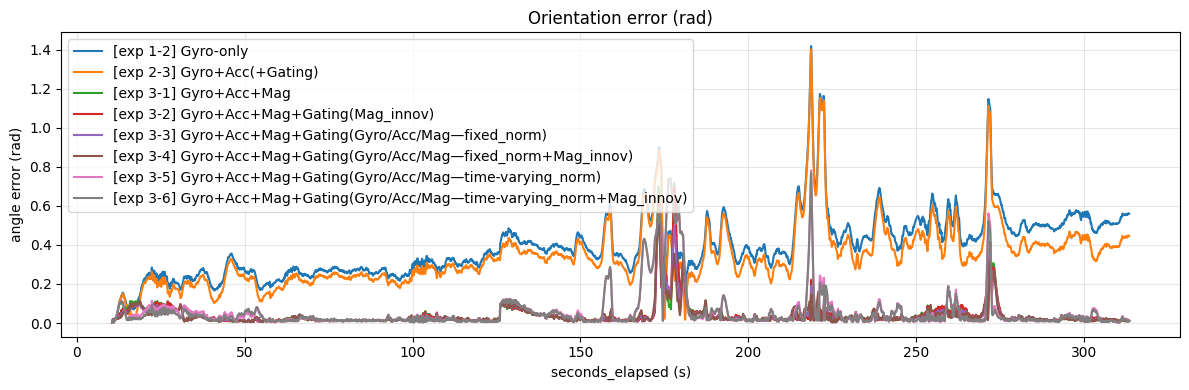

In [13]:
save_err_csv(path_err_1, t_new, angle_err_1)
save_err_csv(path_err_2, t_new, angle_err_2)
save_err_csv(path_err_3, t_new, angle_err_3)
save_err_csv(path_err_4, t_new, angle_err_4)
save_err_csv(path_err_5, t_new, angle_err_5)
save_err_csv(path_err_6, t_new, angle_err_6)

best_exp2 = read_best_from_log(out_dir.parent / "exp_2" /"02_exp2_log.txt", 2)
path_err_exp1_2 = out_dir.parent / "exp_1" / "01_exp1-2_angle_err.csv"
path_err_best_exp2 = out_dir.parent / "exp_2" / f"02_exp{best_exp2}_angle_err.csv"

plot_err_from_csv([
        ("[exp 1-2] Gyro-only", path_err_exp1_2),
        (f"[exp {best_exp2}] Gyro+Acc(+Gating)", path_err_best_exp2),
        ("[exp 3-1] Gyro+Acc+Mag", path_err_1),
        ("[exp 3-2] Gyro+Acc+Mag+Gating(Mag_innov)", path_err_2),
        ("[exp 3-3] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm)", path_err_3),
        ("[exp 3-4] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—fixed_norm+Mag_innov)", path_err_4),
        ("[exp 3-5] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm)", path_err_5),
        ("[exp 3-6] Gyro+Acc+Mag+Gating(Gyro/Acc/Mag—time-varying_norm+Mag_innov)", path_err_6)],
                  path_plot)

In [14]:
with Tee(path_log):
        best: Data = None
        for i in [data_exp1, data_exp2, data_exp3, data_exp4, data_exp5, data_exp6]:
                if best is None or score_angle_err(i.angle_err) < score_angle_err(best.angle_err):
                        best = i

        s: str = best.exp
        s = s[s.find('-')-1 : s.find('-')+2]
        print(f"best: exp{s}")

        [min_angle_err,
         w_acc, w_gyro, w_mag,
         w_total,
         g_est, a_est
         ] = [best.angle_err,
              best.weight_acc, best.weight_gyro, best.weight_mag,
              best.weight_acc*best.weight_gyro + best.mag_gain*best.weight_mag,
              best.g_body_est, best.a_lin_est]



[START] 2026-03-26 17:19:40.614

best: exp3-4

[END] 2026-03-26 17:19:40.631




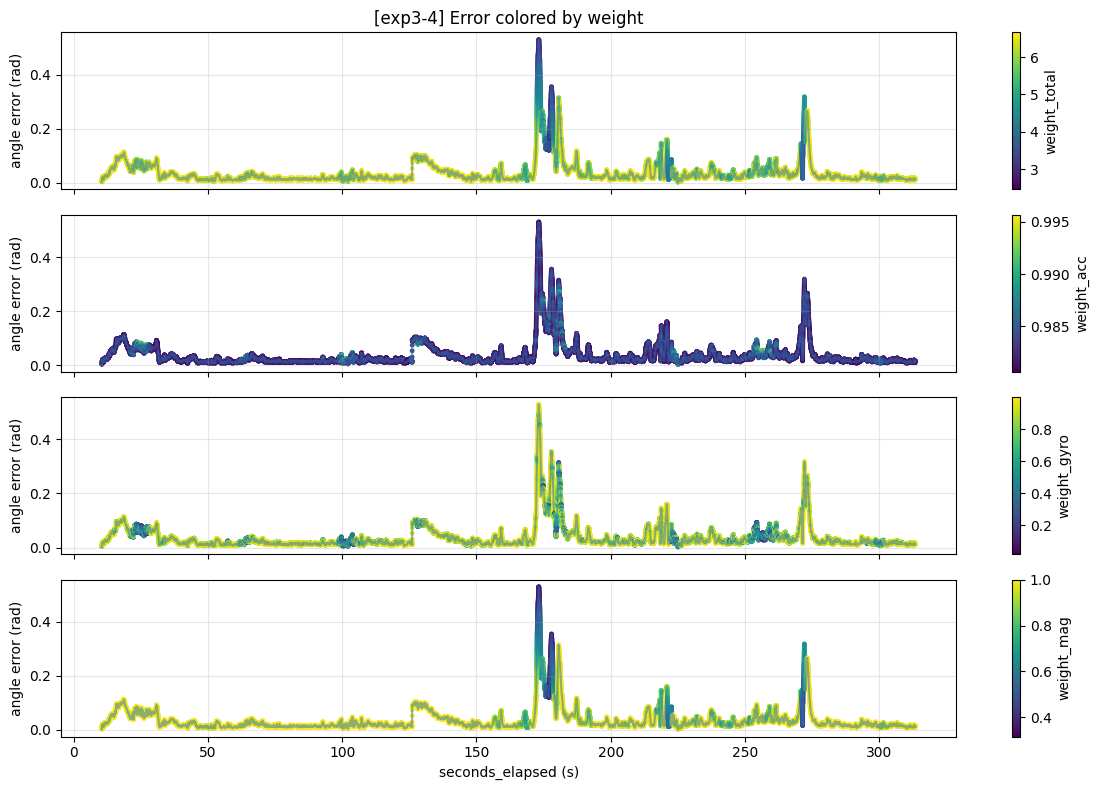

In [15]:
plot_err_colored_by_weight(3, t_new, min_angle_err,
                           w_acc, w_gyro, w_mag, w_total,
                           best.exp, path_plot_weight)

In [16]:
with Tee(path_log):
        print("[Gravity]")
        g_est_sign_fixed, g_rmse_norm = evaluate_estimated_vec3_autosign(g_est, g_ref_interp)
        save_estimated_vec3_csv(path_est_grav, t_new, g_est_sign_fixed)
        err_grav = calc_vec3_direction_angle_err(g_est_sign_fixed, g_ref_interp)
        print("")
        print_err_status("Gravity est/ref", err_grav)
        print("")

        print("\n[Linear accel]")
        a_lin_est_sign_fixed, a_lin_rmse_norm = evaluate_estimated_vec3_autosign(a_est, a_lin_ref_interp)
        save_estimated_vec3_csv(path_est_acc, t_new, a_lin_est_sign_fixed)
        err_acc_lin = calc_vec3_direction_angle_err(a_lin_est_sign_fixed, a_lin_ref_interp)
        print("")
        print_err_status("Linear accel est/ref", err_acc_lin)
        print("")

        print("\n[Consistency ratio]")
        print("rmse_norm of (a_lin_est / g_est): ", a_lin_rmse_norm / max(g_rmse_norm, EPS))



[START] 2026-03-26 17:19:49.213

[Gravity]
RMSE norm: 0.20526433541541741

Gravity est/ref angle error in rad — min/max/mean/p90
0.00016459727972550922 0.09293993934479382 0.017872906262809903 0.033646807603579174

Gravity est/ref angle error in deg — min/max/mean/p90
0.009430729447605911 5.325066272658551 1.0240420964919443 1.9278200697737742


[Linear accel]
RMSE norm: 0.7382335700551836

Linear accel est/ref angle error in rad — min/max/mean/p90
0.000719256919690961 2.824066823648598 0.14232560147445011 0.3241060575267027

Linear accel est/ref angle error in deg — min/max/mean/p90
0.04121038588387206 161.80711005798082 8.154656281146918 18.56990921090433


[Consistency ratio]
rmse_norm of (a_lin_est / g_est):  3.596501888947898

[END] 2026-03-26 17:19:49.653


